In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [5]:
df=pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [4]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [6]:
X=df.drop(columns=['Survived'])
Y=df['Survived']

In [7]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [8]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [9]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [11]:
mean_age=X_train['Age'].mean()
median_age=X_train['Age'].median()

mean_fare=X_train['Fare'].mean()
median_fare=X_train['Fare'].median()

In [17]:
X_train['Age_median']=X_train['Age'].fillna(median_age)
X_train['Age_mean']=X_train['Age'].fillna(mean_age)

X_train['Fare_median']=X_train['Fare'].fillna(median_fare)
X_train['Fare_mean']=X_train['Fare'].fillna(mean_fare)

In [14]:
X_train.sample(6)

,Age,Fare,Family,Age_median,Age_mean,Fare_median
21,34.0,13.0000,0,34.00,34.000000,13.000000
388,NaN,7.7292,0,28.75,29.785904,7.729200
490,NaN,NaN,1,28.75,29.785904,32.617597
83,28.0,47.1000,0,28.00,28.000000,47.100000
704,26.0,7.8542,1,26.00,26.000000,7.854200
242,29.0,10.5000,0,29.00,29.000000,10.500000


In [18]:
print("Original Age variable variance",X_train['Age'].var())
print("Original Age variable variance after imputation",X_train['Age_median'].var())
print("Original Age variable variance after mean imputation",X_train['Age_mean'].var())


print("Original fare variable variance",X_train['Fare'].var())
print("Original fare variable variance after imputation",X_train['Fare_median'].var())
print("Original fare variable variance after mean imputation",X_train['Fare_mean'].var())


Original Age variable variance 204.34951339046142
Original Age variable variance after imputation 161.98956633460548
Original Age variable variance after mean imputation 161.81262452718676
Original fare variable variance 2448.1979137063163
Original fare variable variance after imputation 2340.09102197536
Original fare variable variance after mean imputation 2324.2385256705534


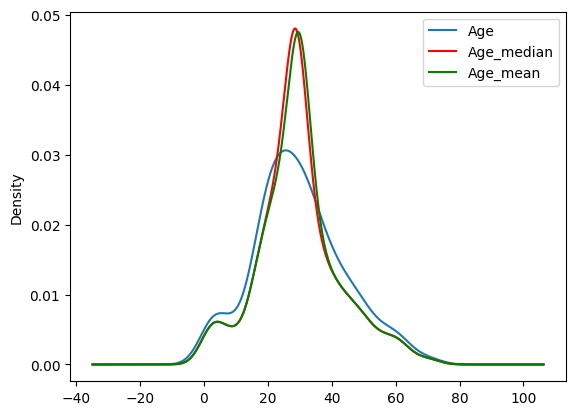

In [ ]:
fig=plt.figure()
ax=fig.add_subplot(111)
# //kernel distribution estimate

#original variable distribution
X_train['Age'].plot(kind='kde',ax=ax)

#variable imputed with the median
X_train['Age_median'].plot(kind='kde',ax=ax,color='red')

#variable imputed with the mean
X_train['Age_mean'].plot(kind='kde',ax=ax,color='green')

lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')